In [36]:
# speed_kmh 주행속도,
# payload_kg,탑승자 및 화물 하중
# ambient_temp_C,외부 기온
# hvac_power_kw,냉난방 사용 전력
# road_grade_pct, 도로 경사도
# battery_temp_C,배터리 온도
# driving_style_index,
# tire_pressure_bar,겨울철 기온 강하로 인한 타이어 공기압 저하 영향
# trip_distance_km, 주행거리(도착지까지의 총 잔여 필요 전력 계산에 사용)

 # < 타겟변수 >
# energy_consumption_kwhper100km (타깃 변수 : 100km당 소비 전력량) 

# 혹서기 혹한기 대비 EV 장거리 주행 안심 내비게이션 도구
#

In [37]:
# warning 무시
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
# '-' 깨짐 해결 모듈
import matplotlib as mpl

import platform
from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

# 마이너스 깨짐 해결
mpl.rcParams["axes.unicode_minus"] = False


Linux system... font set to NanumGothic


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [39]:
df = pd.read_csv('data/ev_energy_consumption.csv')
df

,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883
...,...,...,...,...,...,...,...,...,...,...
7995,50.0,3.8,35.7,2.79,4.80,32.3,0.986,2.11,172.4,23.931
7996,43.0,286.3,11.4,4.20,4.94,17.3,0.643,2.54,130.4,26.811
7997,70.1,358.6,8.9,3.81,-1.50,30.5,0.709,2.16,166.6,26.102
7998,119.9,372.5,1.6,0.59,0.65,17.6,0.757,2.28,172.8,28.355


In [40]:
# 데이터 구조 결측치 확인
df.shape

(8000, 10)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   speed_kmh                       8000 non-null   float64
 1   payload_kg                      8000 non-null   float64
 2   ambient_temp_C                  8000 non-null   float64
 3   hvac_power_kw                   8000 non-null   float64
 4   road_grade_pct                  8000 non-null   float64
 5   battery_temp_C                  8000 non-null   float64
 6   driving_style_index             8000 non-null   float64
 7   tire_pressure_bar               8000 non-null   float64
 8   trip_distance_km                8000 non-null   float64
 9   energy_consumption_kwhper100km  8000 non-null   float64
dtypes: float64(10)
memory usage: 625.1 KB


In [42]:
# 결측치 확인
df.isna().sum()

speed_kmh                         0
payload_kg                        0
ambient_temp_C                    0
hvac_power_kw                     0
road_grade_pct                    0
battery_temp_C                    0
driving_style_index               0
tire_pressure_bar                 0
trip_distance_km                  0
energy_consumption_kwhper100km    0
dtype: int64


=== 핵심 제어 인자와 전비 간의 상관계수 ===
road_grade_pct    0.504623
payload_kg        0.468906
speed_kmh         0.448316
hvac_power_kw     0.369619
Name: energy_consumption_kwhper100km, dtype: float64


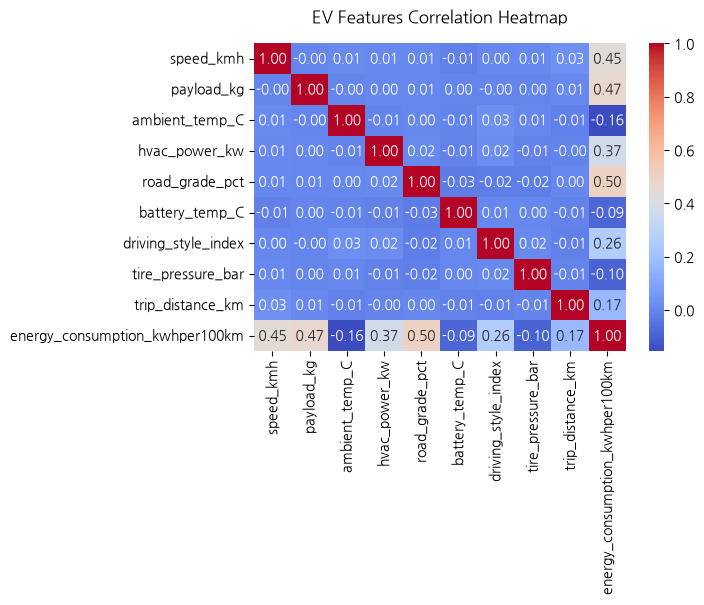

In [43]:
# 상관계수 행렬 연산
corr_matrix = df.corr()

# 주요 4대 영향 인자의 전비 상관계수 별도 출력
target_col = 'energy_consumption_kwhper100km'
key_features = ['speed_kmh', 'payload_kg', 'road_grade_pct', 'hvac_power_kw']
print("\n=== 핵심 제어 인자와 전비 간의 상관계수 ===")
print(corr_matrix[target_col][key_features].sort_values(ascending=False)) #[cite: 2]

# 상관관계 히트맵 시각화
plt.figure(figsize=(6, 4))
sb.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    cbar=True
) 

plt.title('EV Features Correlation Heatmap', pad=15)
plt.show()

In [44]:
# 1. 특성(X)과 타깃(y) 분리
X = df.drop(columns=[target_col]) #[cite: 1, 3]
y = df[target_col] #[cite: 1, 3]

# 2. 학습용(Train)과 검증용(Test) 데이터 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
) #[cite: 1, 3]

# 3. 분할 결과 검증
print("\n=== 데이터 분할 완료 ===")
print(f"X_train 크기: {X_train.shape}, y_train 크기: {y_train.shape}") #[cite: 1, 3]
print(f"X_test 크기: {X_test.shape}, y_test 크기: {y_test.shape}") #[cite: 1, 3]


=== 데이터 분할 완료 ===
X_train 크기: (6400, 9), y_train 크기: (6400,)
X_test 크기: (1600, 9), y_test 크기: (1600,)


## 데이터 분할


In [45]:
# 1. 특성(X)과 타깃(y) 분리
X = df.drop(['energy_consumption_kwhper100km'], axis =1)

In [46]:
X.shape

(8000, 9)

In [47]:
# 100km당 전비 (연속형 수치)
y = df['energy_consumption_kwhper100km']   

In [48]:
y.shape

(8000,)

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   speed_kmh                       8000 non-null   float64
 1   payload_kg                      8000 non-null   float64
 2   ambient_temp_C                  8000 non-null   float64
 3   hvac_power_kw                   8000 non-null   float64
 4   road_grade_pct                  8000 non-null   float64
 5   battery_temp_C                  8000 non-null   float64
 6   driving_style_index             8000 non-null   float64
 7   tire_pressure_bar               8000 non-null   float64
 8   trip_distance_km                8000 non-null   float64
 9   energy_consumption_kwhper100km  8000 non-null   float64
dtypes: float64(10)
memory usage: 625.1 KB


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 전체 8,000개 중 20%(1,600개)를 테스트용으로 분할
    random_state=42      # 언제 실행해도 동일하게 나뉘도록 난수 시드 고정
)

In [51]:
print(f"학습용 X: {X_train.shape}, 학습용 y: {y_train.shape}")
print(f"검증용 X: {X_test.shape},  검증용 y: {y_test.shape}")

학습용 X: (6400, 9), 학습용 y: (6400,)
검증용 X: (1600, 9),  검증용 y: (1600,)


In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. 선형 회귀 모델 객체 생성 및 학습
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)

# 2. 훈련 및 테스트 데이터 예측
lr_train_pred = lr_reg.predict(X_train)
lr_test_pred = lr_reg.predict(X_test)

print("=== [1. Linear Regression 성능 평가] ===")
print(f"Train R² Score : {r2_score(y_train, lr_train_pred):.4f}")
print(f"Test R² Score  : {r2_score(y_test, lr_test_pred):.4f}")
print(f"Test RMSE      : {np.sqrt(mean_squared_error(y_test, lr_test_pred)):.4f}")
print(f"Test MAE       : {mean_absolute_error(y_test, lr_test_pred):.4f} kWh/100km")


=== [1. Linear Regression 성능 평가] ===
Train R² Score : 0.9285
Test R² Score  : 0.9246
Test RMSE      : 1.0093
Test MAE       : 0.8107 kWh/100km


In [ ]:
from lightgbm import LGBMRegressor
# 1. LightGBM 회귀 모델 생성 및 학습
lgb_reg = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
lgb_reg.fit(X_train, y_train)

# 2. 예측 수행
lgb_train_pred = lgb_reg.predict(X_train)
lgb_test_pred = lgb_reg.predict(X_test)

# 3. 성능 평가 지표 출력
print("=== [4. LightGBM Regressor 평가] ===")
print(f"Train R² Score : {r2_score(y_train, lgb_test_pred):.4f}")
print(f"Test R² Score  : {r2_score(y_test, lgb_test_pred):.4f}")
print(f"Test RMSE      : {np.sqrt(mean_squared_error(y_test, lgb_test_pred)):.4f}")
print(f"Test MAE       : {mean_absolute_error(y_test, lgb_test_pred):.4f} kWh/100km")

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. 랜덤 포레스트 회귀 모델 객체 생성 및 학습 (트리 100개)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)

# 2. 예측 수행
rf_train_pred = rf_reg.predict(X_train)
rf_test_pred = rf_reg.predict(X_test)

# 3. 성능 평가 지표 출력
print("=== [2. Random Forest Regressor 평가] ===")
print(f"Train R² Score : {r2_score(y_train, rf_train_pred):.4f}")
print(f"Test R² Score  : {r2_score(y_test, rf_test_pred):.4f}")
print(f"Test RMSE      : {np.sqrt(mean_squared_error(y_test, rf_test_pred)):.4f}")
print(f"Test MAE       : {mean_absolute_error(y_test, rf_test_pred):.4f} kWh/100km")

=== [2. Random Forest Regressor 평가] ===
Train R² Score : 0.9856
Test R² Score  : 0.8987
Test RMSE      : 1.1699
Test MAE       : 0.9299 kWh/100km


In [ ]:
from xgboost import XGBRegressor

# 1. XGBoost 회귀 모델 생성 및 학습
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, verbosity=0)
xgb_reg.fit(X_train, y_train)

# 2. 예측 수행
xgb_train_pred = xgb_reg.predict(X_train)
xgb_test_pred = xgb_reg.predict(X_test)

print("=== [3. XGBoost Regressor 평가] ===")
print(f"Train R² Score : {r2_score(y_train, xgb_train_pred):.4f}")
print(f"Test R² Score  : {r2_score(y_test, xgb_test_pred):.4f}")
print(f"Test RMSE      : {np.sqrt(mean_squared_error(y_test, xgb_test_pred)):.4f}")
print(f"Test MAE       : {mean_absolute_error(y_test, xgb_test_pred):.4f} kWh/100km")

=== [3. XGBoost Regressor 평가] ===
Train R² Score : 0.9777
Test R² Score  : 0.9332
Test RMSE      : 0.9504
Test MAE       : 0.7562 kWh/100km
